<a href="https://www.kaggle.com/code/sonawanelalitsunil/ai-driven-job-matching-ml-xgb?scriptVersionId=226913840" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-powered-job-recommendations/job_recommendation_dataset.csv


## "AI-Driven Job Matching: Smarter Career Recommendations"

## Description:
**Discover how AI transforms job hunting with intelligent job recommendations. By analyzing skills, experience, and industry trends, AI-powered models match candidates with the most relevant opportunities, optimizing career growth and hiring efficiency**

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/ai-powered-job-recommendations/job_recommendation_dataset.csv')

In [3]:
df.head()

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
0,Early years teacher,Richardson Ltd,Sydney,Senior Level,87000.0,Healthcare,Pharmaceuticals
1,Counselling psychologist,"Ramos, Santiago and Stewart",San Francisco,Mid Level,50000.0,Marketing,"Google Ads, SEO, Content Writing"
2,Radio broadcast assistant,Franco Group,New York,Mid Level,77000.0,Healthcare,"Patient Care, Nursing, Medical Research, Pharm..."
3,"Designer, exhibition/display",Collins Inc,Berlin,Senior Level,90000.0,Software,Machine Learning
4,"Psychotherapist, dance movement",Barker Group,Sydney,Entry Level,112000.0,Healthcare,"Nursing, Medical Research, Pharmaceuticals"


In [4]:
df.tail()

,Job Title,Company,Location,Experience Level,Salary,Industry,Required Skills
49995,Veterinary surgeon,"Schultz, Hutchinson and Scott",Bangalore,Senior Level,112000.0,Education,EdTech
49996,Mental health nurse,Garcia-Thompson,New York,Entry Level,150000.0,Software,"Java, Machine Learning, React, AWS"
49997,Field trials officer,Fernandez Group,San Francisco,Mid Level,76000.0,Manufacturing,"Production Planning, Quality Control"
49998,Geographical information systems officer,"Thompson, Jarvis and Campbell",Toronto,Mid Level,137000.0,Marketing,"Social Media, Google Ads, Content Writing"
49999,"Psychotherapist, child","Gonzalez, Scott and Bauer",Bangalore,Mid Level,131000.0,Healthcare,Nursing


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Job Title         50000 non-null  object 
 1   Company           50000 non-null  object 
 2   Location          50000 non-null  object 
 3   Experience Level  50000 non-null  object 
 4   Salary            50000 non-null  float64
 5   Industry          50000 non-null  object 
 6   Required Skills   50000 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.7+ MB


In [6]:
df.describe()

,Salary
count,50000.000000
mean,95145.100000
std,31782.635648
min,40000.000000
25%,68000.000000
50%,95000.000000
75%,123000.000000
max,150000.000000


In [7]:
df.isnull().sum()

Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Job Title            object
Company              object
Location             object
Experience Level     object
Salary              float64
Industry             object
Required Skills      object
dtype: object

In [10]:
df.columns

Index(['Job Title', 'Company', 'Location', 'Experience Level', 'Salary',
       'Industry', 'Required Skills'],
      dtype='object')

## Data Visualizations 

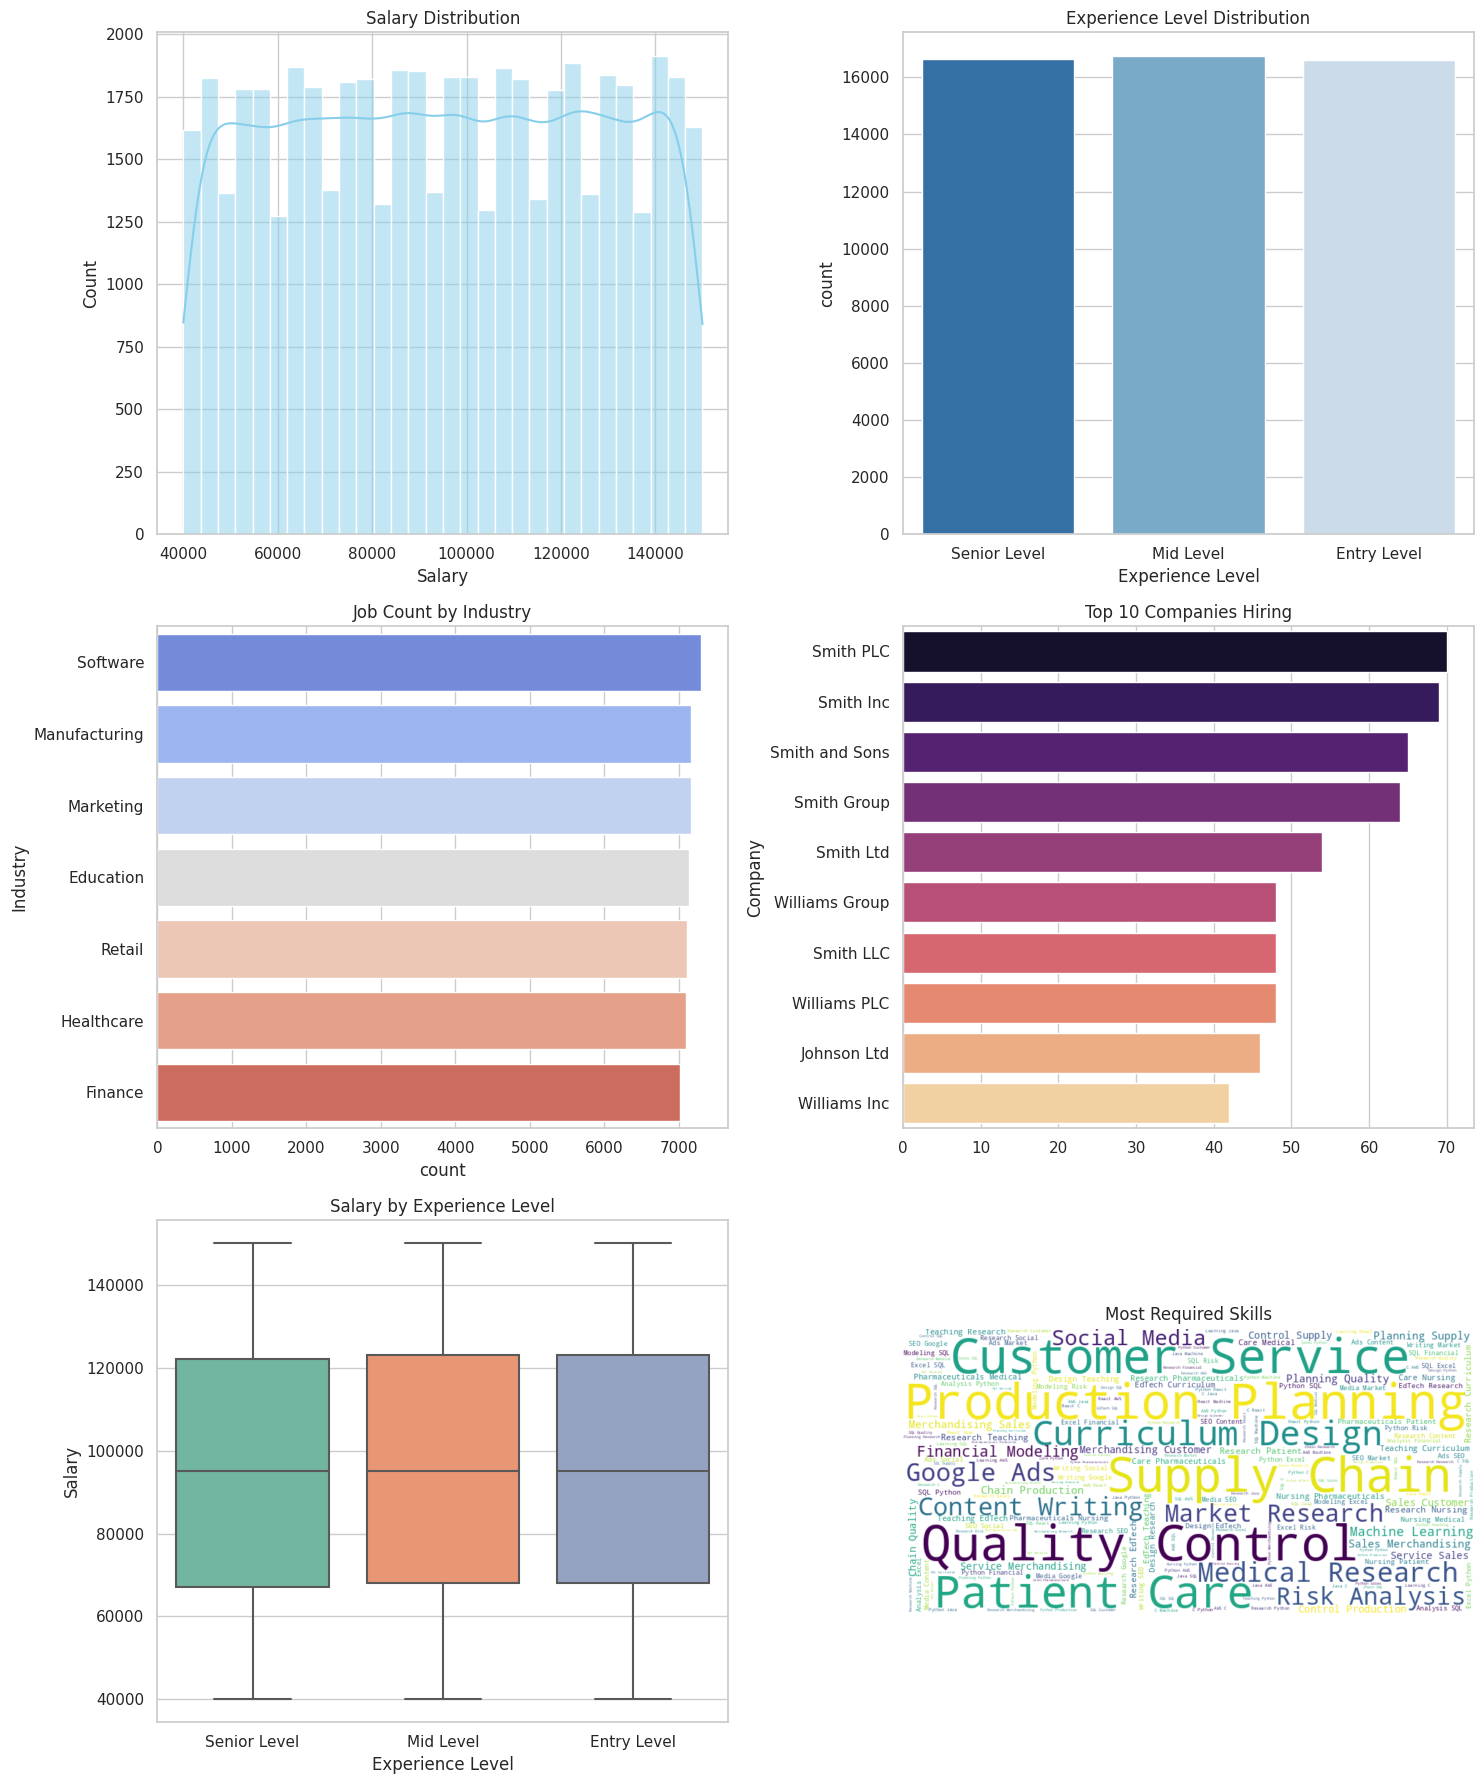

In [11]:
sns.set(style="whitegrid")

# Figure setup
fig, axs = plt.subplots(3, 2, figsize=(15, 18))

# 📌 1. Distribution of Salaries
sns.histplot(df['Salary'], bins=30, kde=True, color='skyblue', ax=axs[0, 0])
axs[0, 0].set_title("Salary Distribution")

# 📌 2. Experience Level Count
sns.countplot(x='Experience Level', data=df, palette='Blues_r', ax=axs[0, 1])
axs[0, 1].set_title("Experience Level Distribution")

# 📌 3. Job Count by Industry
sns.countplot(y='Industry', data=df, order=df['Industry'].value_counts().index, palette='coolwarm', ax=axs[1, 0])
axs[1, 0].set_title("Job Count by Industry")

# 📌 4. Top Companies Hiring
top_companies = df['Company'].value_counts().nlargest(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma', ax=axs[1, 1])
axs[1, 1].set_title("Top 10 Companies Hiring")

# 📌 5. Salary by Experience Level
sns.boxplot(x='Experience Level', y='Salary', data=df, palette='Set2', ax=axs[2, 0])
axs[2, 0].set_title("Salary by Experience Level")

# 📌 6. Most Required Skills (Word Cloud)
from wordcloud import WordCloud
skills_text = ' '.join(df['Required Skills'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(skills_text)

# Display WordCloud
axs[2, 1].imshow(wordcloud, interpolation='bilinear')
axs[2, 1].axis('off')
axs[2, 1].set_title("Most Required Skills")

plt.tight_layout()
plt.show()

## Predictive modeling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [13]:
# Features and target variable
features = ['Experience Level', 'Industry']
target = 'Salary'

In [14]:
# One-Hot Encoding for categorical features
model_df = pd.get_dummies(df[features + [target]], columns=features, drop_first=True)

In [15]:
# Feature matrix and target vector
X = model_df.drop(columns=[target])
y = model_df[target]

In [16]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Initialize ML models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Machine": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

In [18]:
# Dictionary to store performance metrics
model_results = {}

In [19]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    y_pred = model.predict(X_test)  # Predict salary
    
    # Evaluate using R² Score and RMSE
    r2 = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    
    # Store results
    model_results[name] = {"R² Score": r2, "RMSE": rmse}

In [20]:
# Convert results to DataFrame
results_df = pd.DataFrame(model_results).T

In [21]:
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)

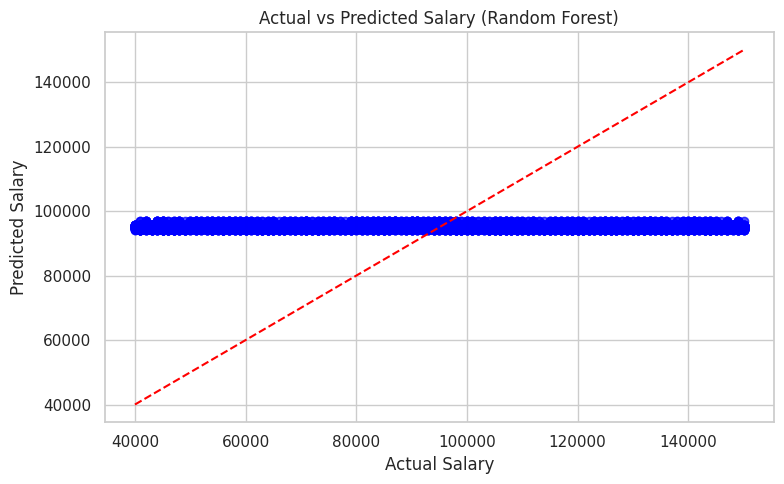

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_best, alpha=0.7, color="blue")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Random Forest)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")  # Ideal Line
plt.tight_layout()
plt.show()

In [23]:
results_df

,R² Score,RMSE
Linear Regression,-0.000039,32001.124916
Random Forest,-0.000565,32009.540164
Support Vector Machine,-0.000097,32002.046436
K-Nearest Neighbors,-0.238775,35616.632070
XGBoost,-0.000552,32009.321885


## Thank you!!!...upvotes!!!